# Importing Libraries and Settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

print("All libraries imported successfully")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")

All libraries imported successfully
Pandas version: 3.0.3
Numpy version: 2.3.5


# CELL 2 — Load Raw Dataset with Stratified Sampling

In [4]:
# Step 1: Load full dataset with only essential columns
# Using usecols keeps memory usage low on 8GB RAM
essential_cols = [
    'id', 'issue_d', 'loan_status', 'loan_amnt', 'funded_amnt',
    'term', 'int_rate', 'installment', 'grade', 'sub_grade',
    'purpose', 'emp_length', 'home_ownership', 'annual_inc',
    'verification_status', 'dti', 'earliest_cr_line',
    'fico_range_low', 'fico_range_high', 'open_acc', 'pub_rec',
    'revol_bal', 'revol_util', 'total_acc', 'inq_last_6mths',
    'delinq_2yrs', 'recoveries', 'collection_recovery_fee',
    'total_rec_prncp', 'out_prncp'
]

df_full = pd.read_csv(
    '../data/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv',
    usecols=essential_cols,
    low_memory=False
)

print(f"✅ Full dataset loaded")
print(f"   Total rows    : {df_full.shape[0]:,}")
print(f"   Total columns : {df_full.shape[1]}")

# Step 2: Extract year from issue_d
# issue_d format is 'Jan-2015', 'Mar-2018' etc.
df_full['issue_year'] = pd.to_datetime(
    df_full['issue_d'], format='%b-%Y'
).dt.year

print(f"\n=== LOAN DISTRIBUTION BY YEAR (Full Dataset) ===\n")
year_counts = df_full['issue_year'].value_counts().sort_index()
for year, count in year_counts.items():
    pct = count / len(df_full) * 100
    bar = '█' * int(pct / 0.5)
    print(f"   {year} : {count:>7,} ({pct:>5.1f}%) {bar}")

# Step 3: Stratified sample — 200K rows proportional by year
# FIX: Use explicit loop instead of groupby.apply
# groupby.apply in pandas 3.0 drops the grouping column
SAMPLE_SIZE = 200_000
total = len(df_full)

frames = []
for year, group in df_full.groupby('issue_year'):
    n = max(1, int(round(SAMPLE_SIZE * len(group) / total)))
    n = min(n, len(group))
    frames.append(group.sample(n=n, random_state=42))

df = pd.concat(frames).reset_index(drop=True)

# Trim to exactly 200K if rounding gave slightly more
if len(df) > SAMPLE_SIZE:
    df = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)

print(f"\n✅ Stratified sample created")
print(f"   Sample size : {len(df):,} rows")
print(f"\n=== YEAR DISTRIBUTION IN SAMPLE ===\n")
sample_year = df['issue_year'].value_counts().sort_index()
for year, count in sample_year.items():
    pct = count / len(df) * 100
    bar = '█' * int(pct / 0.5)
    print(f"   {year} : {count:>6,} ({pct:>5.1f}%) {bar}")

print(f"\n✅ issue_year column present: {'issue_year' in df.columns}")
print(f"✅ out_prncp column present : {'out_prncp' in df.columns}")

✅ Full dataset loaded
   Total rows    : 2,260,701
   Total columns : 30

=== LOAN DISTRIBUTION BY YEAR (Full Dataset) ===

   2007.0 :     603 (  0.0%) 
   2008.0 :   2,393 (  0.1%) 
   2009.0 :   5,281 (  0.2%) 
   2010.0 :  12,537 (  0.6%) █
   2011.0 :  21,721 (  1.0%) █
   2012.0 :  53,367 (  2.4%) ████
   2013.0 : 134,814 (  6.0%) ███████████
   2014.0 : 235,629 ( 10.4%) ████████████████████
   2015.0 : 421,095 ( 18.6%) █████████████████████████████████████
   2016.0 : 434,407 ( 19.2%) ██████████████████████████████████████
   2017.0 : 443,579 ( 19.6%) ███████████████████████████████████████
   2018.0 : 495,242 ( 21.9%) ███████████████████████████████████████████

✅ Stratified sample created
   Sample size : 199,997 rows

=== YEAR DISTRIBUTION IN SAMPLE ===

   2007.0 :     53 (  0.0%) 
   2008.0 :    212 (  0.1%) 
   2009.0 :    467 (  0.2%) 
   2010.0 :  1,109 (  0.6%) █
   2011.0 :  1,922 (  1.0%) █
   2012.0 :  4,721 (  2.4%) ████
   2013.0 : 11,927 (  6.0%) ███████████
   20

#  CELL 3 — Confirm Selected Columns

In [5]:
print(f"✅ Column selection complete")
print(f"   Total columns loaded : {df.shape[1]}")
print(f"   Rows                 : {df.shape[0]:,}")
print(f"\n--- SELECTED COLUMNS ---\n")
for i, col in enumerate(df.columns):
    null_pct = (df[col].isnull().sum() / len(df)) * 100
    print(f"  {i+1:>2}. {col:<45} | {null_pct:.1f}% null")

✅ Column selection complete
   Total columns loaded : 31
   Rows                 : 199,997

--- SELECTED COLUMNS ---

   1. id                                            | 0.0% null
   2. loan_amnt                                     | 0.0% null
   3. funded_amnt                                   | 0.0% null
   4. term                                          | 0.0% null
   5. int_rate                                      | 0.0% null
   6. installment                                   | 0.0% null
   7. grade                                         | 0.0% null
   8. sub_grade                                     | 0.0% null
   9. emp_length                                    | 6.5% null
  10. home_ownership                                | 0.0% null
  11. annual_inc                                    | 0.0% null
  12. verification_status                           | 0.0% null
  13. issue_d                                       | 0.0% null
  14. loan_status                                 

# CELL 4 — Analyse Target Variable: loan_status

In [6]:
print("LOAN STATUS DISTRIBUTION\n")

status_counts = df['loan_status'].value_counts()
status_pct = df['loan_status'].value_counts(normalize=True) * 100

for status, count in status_counts.items():
    pct = status_pct[status]
    bar = '█' * int(pct)
    print(f"{status:<40} | {count:>7,} | {pct:>5.1f}% | {bar}")

LOAN STATUS DISTRIBUTION

Fully Paid                               |  95,388 |  47.7% | ███████████████████████████████████████████████
Current                                  |  77,653 |  38.8% | ██████████████████████████████████████
Charged Off                              |  23,738 |  11.9% | ███████████
Late (31-120 days)                       |   1,900 |   1.0% | 
In Grace Period                          |     736 |   0.4% | 
Late (16-30 days)                        |     362 |   0.2% | 
Does not meet the credit policy. Status:Fully Paid |     154 |   0.1% | 
Does not meet the credit policy. Status:Charged Off |      65 |   0.0% | 
Default                                  |       1 |   0.0% | 


# CELL 5 — Creating Binary Target Variable for PD Model

In [7]:

# Default (1): Charged Off, Late, In Grace Period, Default
# Non-Default (0): Fully Paid
# Dropped: Current (outcome unknown — still ongoing)

# Keep only conclusive loans — drop 'Current'
df = df[df['loan_status'] != 'Current'].copy()

# Map to binary target
default_statuses = [
    'Charged Off',
    'Late (31-120 days)',
    'Late (16-30 days)',
    'In Grace Period',
    'Default'
]

df['default'] = df['loan_status'].apply(
    lambda x: 1 if x in default_statuses else 0
)

# Summary
total = len(df)
defaults = df['default'].sum()
non_defaults = total - defaults

print(f" Binary target variable created")
print(f"\n   Total loans (after dropping Current) : {total:,}")
print(f"   Default     (1)                       : {defaults:,} ({defaults/total*100:.1f}%)")
print(f"   Non-Default (0)                       : {non_defaults:,} ({non_defaults/total*100:.1f}%)")
print(f"\n   Class imbalance ratio : 1 default for every {non_defaults//defaults} non-defaults")
print(f"   → Will use class_weight='balanced' in modelling phase (no SMOTE)")

 Binary target variable created

   Total loans (after dropping Current) : 122,344
   Default     (1)                       : 26,737 (21.9%)
   Non-Default (0)                       : 95,607 (78.1%)

   Class imbalance ratio : 1 default for every 3 non-defaults
   → Will use class_weight='balanced' in modelling phase (no SMOTE)


# CELL 6 — Data Cleaning

In [8]:
print("=== BEFORE CLEANING ===")
print(f"Shape: {df.shape}\n")

# --- 1. Clean 'term' — remove ' months' and convert to integer ---
df['term'] = df['term'].str.strip().str.replace(' months', '').astype(int)

# --- 2. Clean 'int_rate' — already float, confirm ---
df['int_rate'] = df['int_rate'].astype(float)

# --- 3. Clean 'emp_length' ---
# Map employment length to numeric values
emp_map = {
    '< 1 year': 0,
    '1 year':   1,
    '2 years':  2,
    '3 years':  3,
    '4 years':  4,
    '5 years':  5,
    '6 years':  6,
    '7 years':  7,
    '8 years':  8,
    '9 years':  9,
    '10+ years':10
}
df['emp_length'] = df['emp_length'].map(emp_map)
# Fill missing emp_length with median
df['emp_length'] = df['emp_length'].fillna(df['emp_length'].median())

# --- 4. Create single FICO score from low and high ---
df['fico_score'] = (df['fico_range_low'] + df['fico_range_high']) / 2
df.drop(columns=['fico_range_low', 'fico_range_high'], inplace=True)

# --- 5. Extract credit history length in years ---
from datetime import datetime
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
df['credit_history_years'] = (
    (pd.Timestamp.now() - df['earliest_cr_line']).dt.days / 365
).round(1)
df.drop(columns=['earliest_cr_line'], inplace=True)

# --- 6. Drop rows with any remaining nulls ---
before = len(df)
df.dropna(inplace=True)
after = len(df)

print(f"=== AFTER CLEANING ===")
print(f"Shape        : {df.shape}")
print(f"Rows dropped : {before - after:,}")
print(f"\n=== CLEANED COLUMN DTYPES ===\n")
for col in df.columns:
    print(f"  {col:<35} | {str(df[col].dtype):<10}")

=== BEFORE CLEANING ===
Shape: (122344, 32)

=== AFTER CLEANING ===
Shape        : (122216, 31)
Rows dropped : 128

=== CLEANED COLUMN DTYPES ===

  id                                  | str       
  loan_amnt                           | float64   
  funded_amnt                         | float64   
  term                                | int64     
  int_rate                            | float64   
  installment                         | float64   
  grade                               | str       
  sub_grade                           | str       
  emp_length                          | float64   
  home_ownership                      | str       
  annual_inc                          | float64   
  verification_status                 | str       
  issue_d                             | str       
  loan_status                         | str       
  purpose                             | str       
  dti                                 | float64   
  delinq_2yrs                        

# Exploratory Data Analysis with visualisations:

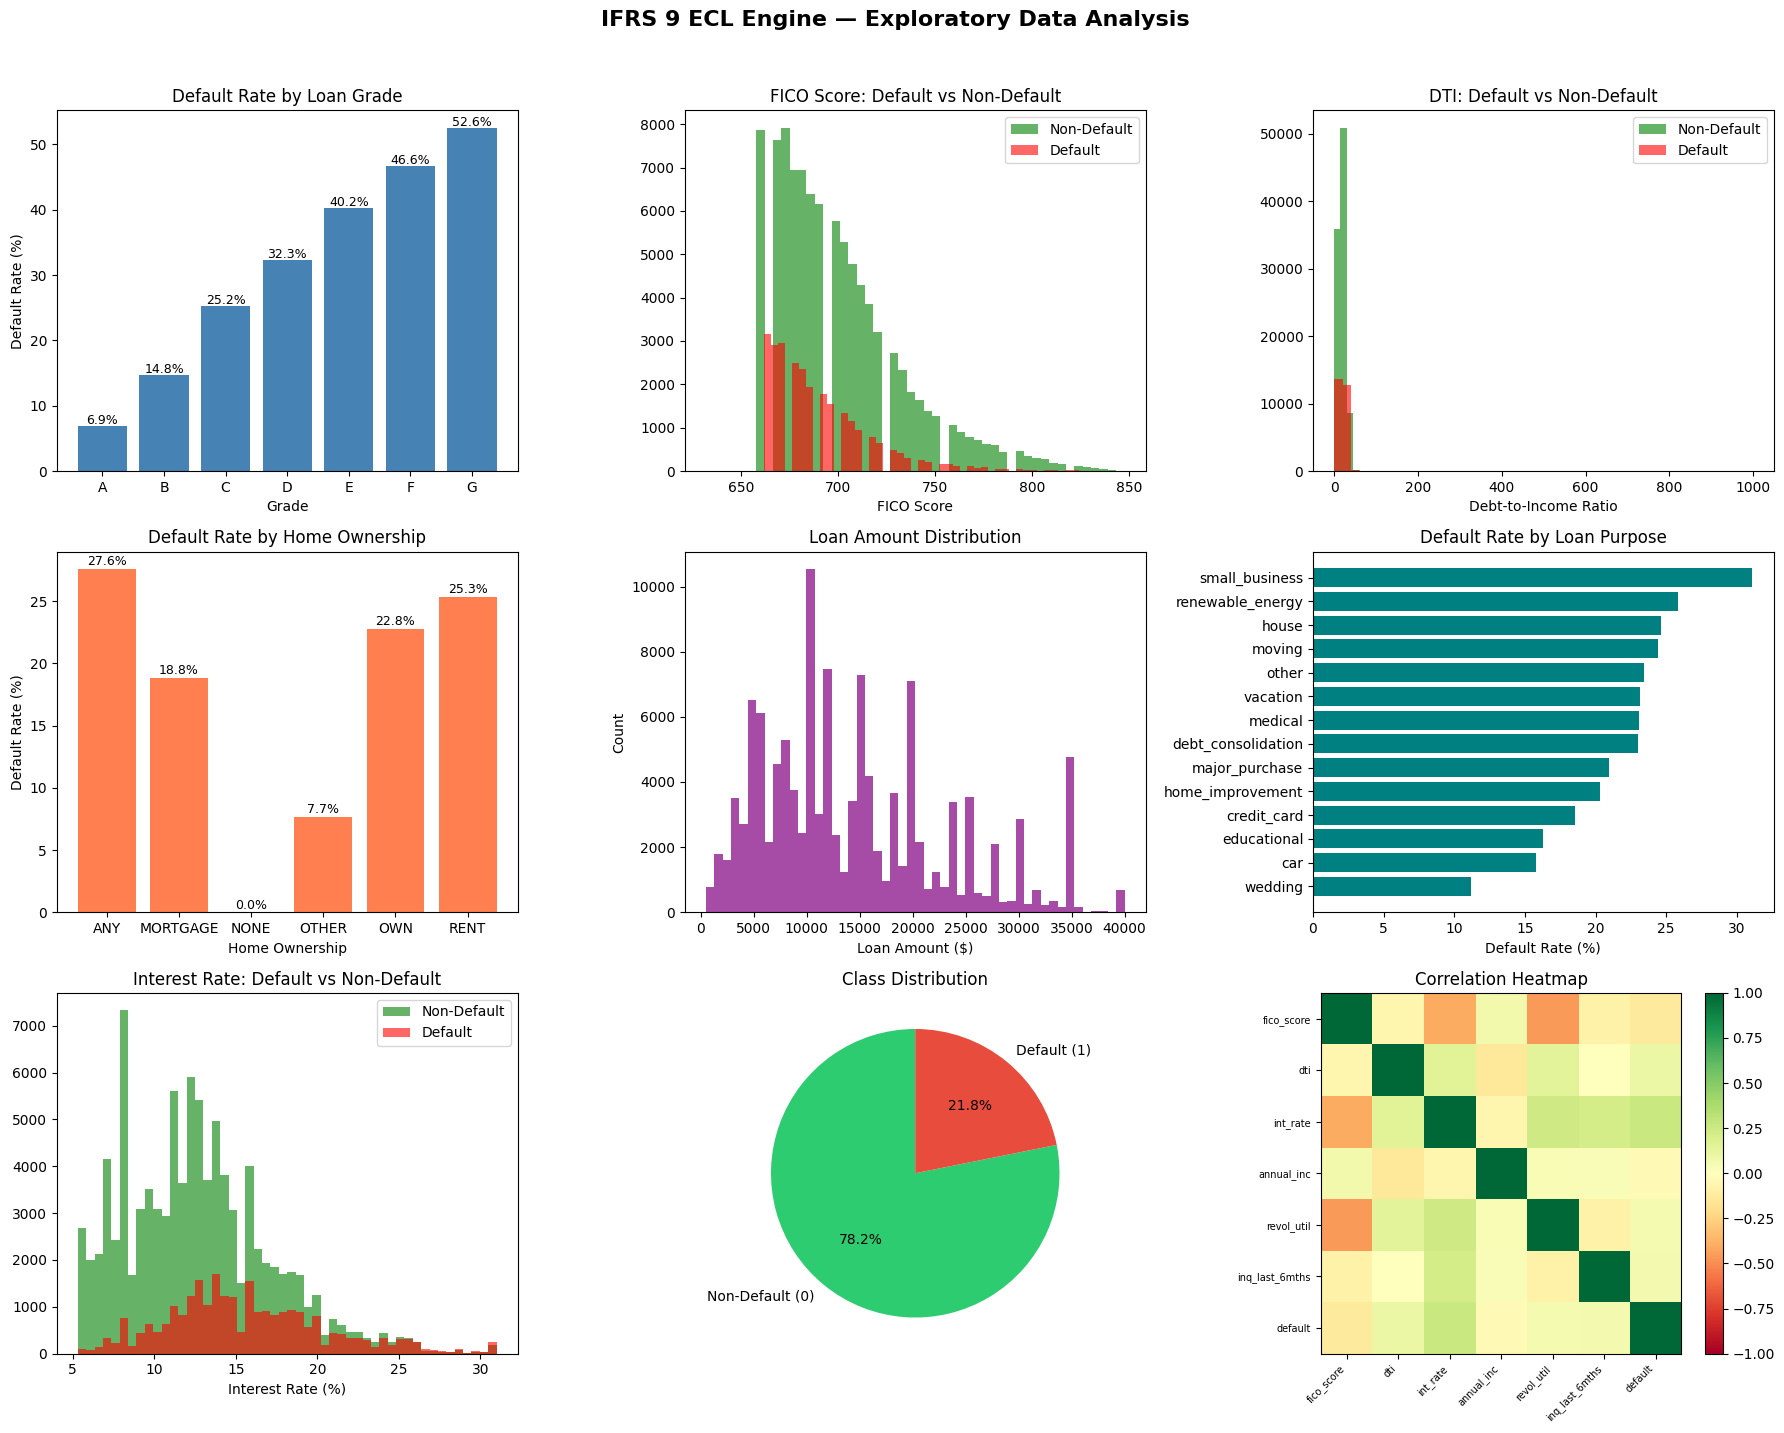

✅ EDA plots saved to reports/eda_plots.png


In [9]:
# CELL 7 — Exploratory Data Analysis (EDA)

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('IFRS 9 ECL Engine — Exploratory Data Analysis', 
             fontsize=16, fontweight='bold', y=1.02)

# --- 1. Default Rate by Grade ---
grade_default = df.groupby('grade')['default'].mean() * 100
axes[0,0].bar(grade_default.index, grade_default.values, color='steelblue')
axes[0,0].set_title('Default Rate by Loan Grade')
axes[0,0].set_xlabel('Grade')
axes[0,0].set_ylabel('Default Rate (%)')
for i, v in enumerate(grade_default.values):
    axes[0,0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

# --- 2. FICO Score Distribution ---
axes[0,1].hist(df[df['default']==0]['fico_score'], bins=50, 
               alpha=0.6, label='Non-Default', color='green')
axes[0,1].hist(df[df['default']==1]['fico_score'], bins=50, 
               alpha=0.6, label='Default', color='red')
axes[0,1].set_title('FICO Score: Default vs Non-Default')
axes[0,1].set_xlabel('FICO Score')
axes[0,1].legend()

# --- 3. DTI Distribution ---
axes[0,2].hist(df[df['default']==0]['dti'], bins=50, 
               alpha=0.6, label='Non-Default', color='green')
axes[0,2].hist(df[df['default']==1]['dti'], bins=50, 
               alpha=0.6, label='Default', color='red')
axes[0,2].set_title('DTI: Default vs Non-Default')
axes[0,2].set_xlabel('Debt-to-Income Ratio')
axes[0,2].legend()

# --- 4. Default Rate by Home Ownership ---
home_default = df.groupby('home_ownership')['default'].mean() * 100
axes[1,0].bar(home_default.index, home_default.values, color='coral')
axes[1,0].set_title('Default Rate by Home Ownership')
axes[1,0].set_xlabel('Home Ownership')
axes[1,0].set_ylabel('Default Rate (%)')
for i, v in enumerate(home_default.values):
    axes[1,0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

# --- 5. Loan Amount Distribution ---
axes[1,1].hist(df['loan_amnt'], bins=50, color='purple', alpha=0.7)
axes[1,1].set_title('Loan Amount Distribution')
axes[1,1].set_xlabel('Loan Amount ($)')
axes[1,1].set_ylabel('Count')

# --- 6. Default Rate by Purpose ---
purpose_default = df.groupby('purpose')['default'].mean() * 100
purpose_default = purpose_default.sort_values(ascending=True)
axes[1,2].barh(purpose_default.index, purpose_default.values, color='teal')
axes[1,2].set_title('Default Rate by Loan Purpose')
axes[1,2].set_xlabel('Default Rate (%)')

# --- 7. Interest Rate vs Default ---
axes[2,0].hist(df[df['default']==0]['int_rate'], bins=50,
               alpha=0.6, label='Non-Default', color='green')
axes[2,0].hist(df[df['default']==1]['int_rate'], bins=50,
               alpha=0.6, label='Default', color='red')
axes[2,0].set_title('Interest Rate: Default vs Non-Default')
axes[2,0].set_xlabel('Interest Rate (%)')
axes[2,0].legend()

# --- 8. Class Imbalance ---
labels = ['Non-Default (0)', 'Default (1)']
sizes = [df['default'].value_counts()[0], df['default'].value_counts()[1]]
colors = ['#2ecc71', '#e74c3c']
axes[2,1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[2,1].set_title('Class Distribution')

# --- 9. Correlation Heatmap ---
numeric_cols = ['fico_score', 'dti', 'int_rate', 'annual_inc', 
                'revol_util', 'inq_last_6mths', 'default']
corr = df[numeric_cols].corr()
im = axes[2,2].imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
axes[2,2].set_xticks(range(len(numeric_cols)))
axes[2,2].set_yticks(range(len(numeric_cols)))
axes[2,2].set_xticklabels(numeric_cols, rotation=45, ha='right', fontsize=7)
axes[2,2].set_yticklabels(numeric_cols, fontsize=7)
axes[2,2].set_title('Correlation Heatmap')
plt.colorbar(im, ax=axes[2,2])

plt.tight_layout()
plt.savefig('../reports/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved to reports/eda_plots.png")

# Saving Clean Data

In [10]:
# Save cleaned dataframe for use in next notebooks

df.to_csv('../data/cleaned_loan_data.csv', index=False)

print(f"  Cleaned dataset saved to data/cleaned_loan_data.csv")
print(f"   Rows    : {df.shape[0]:,}")
print(f"   Columns : {df.shape[1]}")
print(f"\n EDA & Cleaning complete!")
print(f"   Next step → 02_pd_model.ipynb")

  Cleaned dataset saved to data/cleaned_loan_data.csv
   Rows    : 122,216
   Columns : 31

 EDA & Cleaning complete!
   Next step → 02_pd_model.ipynb
